# Predicting Food Insecurity Risk from Conflict Dynamics in South Sudan

**Author:** Ajak Chol  
**Module:** Introduction to Machine Learning — Summative Project - Model Training and Evaluation 
**Date:** 24/June/2026

**GitHub:**  https://github.com/SLICKMAN-TYRUS/south-sudan-conflict-food-security-ml.git
**Demo video:** https://drive.google.com/drive/folders/1DUYqIahGVkO0ylwS6aLjE9tTVxMb84Ye?usp=sharing 

---

# Conflict-Driven Food Security Forecasting in South Sudan

**Mission Alignment:** This project supports the goal of improving humanitarian decision-making and promoting sustainable development in South Sudan and other conflict-affected regions. By investigating whether county-level conflict patterns can be used to anticipate food insecurity, the project demonstrates how machine learning can support earlier interventions, better resource allocation, and more informed peacebuilding efforts.

**Problem Statement:** South Sudan has experienced prolonged armed conflict since gaining independence in 2011, with violence continuing to disrupt livelihoods, agricultural production, and access to food. As a result, millions of people experience acute food insecurity each year, creating an ongoing need for timely humanitarian assistance. Although organizations such as FEWS NET and IPC provide detailed food security assessments, these assessments are produced periodically and may not always provide sufficient lead time for proactive intervention.

At the same time, conflict events are reported continuously through datasets such as ACLED, raising an important question:

> **Can historical conflict event data be used to predict the likelihood of a county experiencing a food security crisis one month in advance?**

To answer this question, this project combines conflict event data from ACLED with county-level IPC food security classifications and develops a complete machine learning pipeline to compare traditional machine learning models with deep learning approaches. The models are evaluated using metrics appropriate for an imbalanced classification problem, with **ROC-AUC used as the primary performance metric** because it provides a more reliable measure of a model's ability to distinguish between crisis and non-crisis conditions than overall accuracy.

The outcome of this project is not intended to replace existing humanitarian assessments. Instead, it demonstrates how conflict data can be transformed into an additional early-warning signal that could help humanitarian agencies identify high-risk counties sooner and support more timely, evidence-based decision-making.


## 0. Setup and Reproducibility

All dependencies are installed below. Random seeds are fixed before any data is loaded so results are fully reproducible from a fresh kernel.

In [2]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
print(tf.__version__)

from tensorflow import keras

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

import sys
sys.path.insert(0, '..')
from src.data_loading import load_acled, load_ipc
from src.preprocessing import (
    standardize_county_names, filter_ipc, find_unmatched_counties,
    aggregate_acled_to_county_month, pivot_ipc_wide, merge_conflict_food_security,
)

print('TensorFlow version:', tf.__version__)
print('Setup complete. SEED =', SEED)

2.21.0
TensorFlow version: 2.21.0
Setup complete. SEED = 42


1. Data Loading

The first step is to import the two primary datasets used throughout this project. The ACLED dataset provides detailed records of conflict events across South Sudan, while the FEWS NET IPC dataset contains food security assessments over time. Before any preprocessing or modelling begins, the datasets are inspected to verify their dimensions, temporal coverage, data quality, and completeness. This preliminary validation helps identify potential issues that could affect downstream analysis.

In [3]:
acled_raw = load_acled('../data/raw/acled_south_sudan.csv')
ipc_raw   = load_ipc('../data/raw/fewsnet_ipc_south_sudan.csv')

print('ACLED shape:', acled_raw.shape)
print('ACLED date range:', acled_raw['event_date'].min().date(), '->', acled_raw['event_date'].max().date())
print()
print('IPC shape:', ipc_raw.shape)
print('IPC date range:', ipc_raw['From'].min().date(), '->', ipc_raw['From'].max().date())
print()
print('ACLED missing values (non-zero only):')
miss = acled_raw.isnull().sum()
print(miss[miss > 0])
print('IPC missing values:', ipc_raw.isnull().sum().sum())

ACLED shape: (15725, 32)
ACLED date range: 2011-05-19 -> 2025-06-21

IPC shape: (25357, 11)
IPC date range: 2017-01-01 -> 2026-04-01

ACLED missing values (non-zero only):
assoc_actor_1         10192
actor2                  756
assoc_actor_2          7412
inter2                  756
civilian_targeting     8698
admin3                   40
tags                  14737
population_best        3229
dtype: int64
IPC missing values: 0


Interpretation

The datasets loaded successfully and contain sufficient historical information for predictive modelling. The ACLED dataset spans from May 2011 to June 2025, while the IPC assessments extend into April 2026, creating a natural forecasting window for predicting future food security conditions. Missing values are primarily confined to descriptive ACLED variables such as secondary actors and associated actor fields, which are expected because not every conflict event involves multiple participants. In contrast, the IPC dataset contains no missing values, providing a reliable target variable for supervised learning.

## 2. Exploratory Data Analysis

Before preparing the data for machine learning, it is important to understand the temporal and spatial characteristics of both datasets. The following visualizations examine conflict trends, event composition, fatality distributions, and food security patterns to identify relationships that may influence model performance and guide feature engineering decisions.

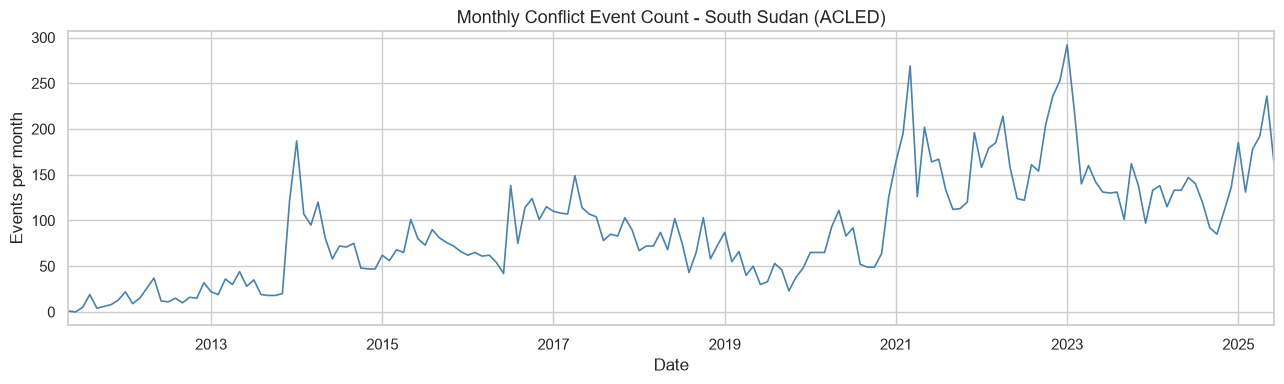

In [ ]:
## 2.1. Events over time

fig, ax = plt.subplots(figsize=(13,4))
acled_raw.set_index('event_date').resample('ME').size().plot(ax=ax, color='steelblue', linewidth=1.2)
ax.set_title('Monthly Conflict Event Count - South Sudan (ACLED)', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Events per month')
plt.tight_layout()
plt.savefig('../reports/figures/01_events_per_month.png', dpi=150)
plt.show()

## Interpretation

Monthly conflict activity varies considerably throughout the observation period, with several pronounced spikes indicating periods of intensified violence. These increases align closely with major phases of instability in South Sudan, including the civil conflict that began in late 2013 and subsequent periods of renewed violence. The absence of a stable long-term pattern suggests that conflict evolves dynamically over time, supporting the inclusion of temporal lag features that allow the models to capture delayed effects on food security.

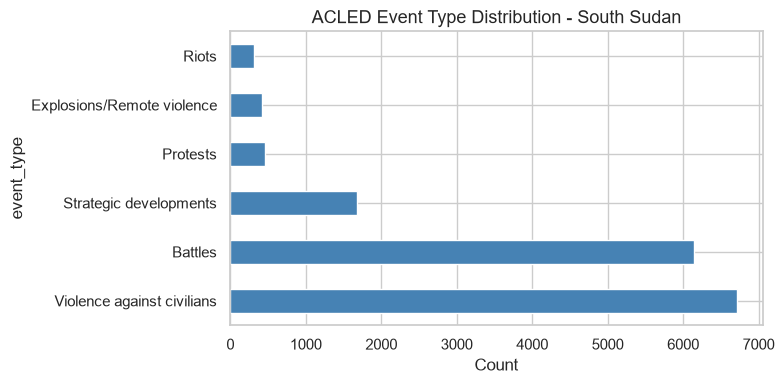

In [ ]:
## 2.2. Event type distribution

fig, ax = plt.subplots(figsize=(8,4))
acled_raw['event_type'].value_counts().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('ACLED Event Type Distribution - South Sudan', fontsize=13)
ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig('../reports/figures/02_event_type_distribution.png', dpi=150)
plt.show()

## Interpretation

Violence against civilians and battles account for the largest proportion of recorded conflict events, indicating that direct armed violence dominates the dataset. This distribution suggests that civilian exposure to conflict is a major characteristic of the humanitarian environment in South Sudan. Since these event types occur frequently throughout the study period, they are expected to provide strong predictive signals when estimating subsequent food security conditions.

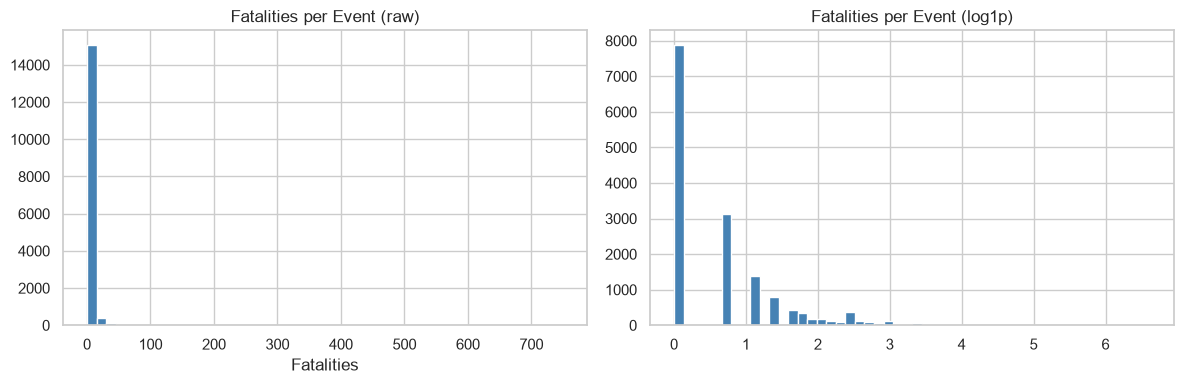

Max: 750  Mean: 3.15  Zero-fatality events: 7894


In [ ]:
## 2.3. Fatalities distribution

fig, axes = plt.subplots(1,2, figsize=(12,4))
acled_raw['fatalities'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Fatalities per Event (raw)'); axes[0].set_xlabel('Fatalities')
np.log1p(acled_raw['fatalities']).hist(bins=50, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Fatalities per Event (log1p)')
plt.tight_layout()
plt.savefig('../reports/figures/03_fatalities_distribution.png', dpi=150)
plt.show()
print('Max:', acled_raw['fatalities'].max(), ' Mean:', round(acled_raw['fatalities'].mean(),2),
      ' Zero-fatality events:', (acled_raw['fatalities']==0).sum())

## Interpretation

The fatality distribution is heavily right-skewed, with most conflict events recording few or no fatalities and a small number of extremely severe incidents producing a long tail. Applying a logarithmic transformation reduces the influence of these extreme values while preserving their relative importance within the dataset. This preprocessing step improves numerical stability and allows both classical machine learning algorithms and neural networks to learn from the data more effectively.

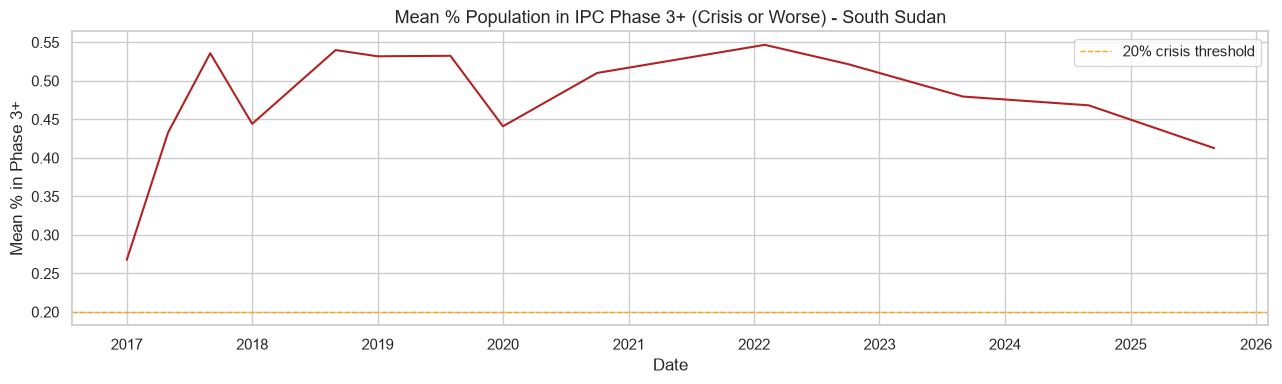

In [ ]:
## 2.4. IPC Phase 3+ trend

ipc_cur_eda = ipc_raw[ipc_raw['Validity period']=='current'].copy()
ipc_3plus   = ipc_cur_eda[ipc_cur_eda['Phase']=='3+'][['From','Percentage']].groupby('From')['Percentage'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13,4))
ax.plot(ipc_3plus['From'], ipc_3plus['Percentage'], color='firebrick', linewidth=1.5)
ax.axhline(0.20, color='orange', linestyle='--', linewidth=1, label='20% crisis threshold')
ax.set_title('Mean % Population in IPC Phase 3+ (Crisis or Worse) - South Sudan', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Mean % in Phase 3+'); ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/04_ipc_phase3plus_trend.png', dpi=150)
plt.show()

## Interpretation

The IPC Phase 3+ trend indicates that food insecurity remains consistently above the 20% crisis threshold throughout much of the study period, although its severity changes over time. Periods of increasing food insecurity broadly coincide with sustained increases in conflict activity observed earlier, suggesting a meaningful temporal relationship between violence and humanitarian conditions. This reinforces the motivation for using historical conflict information to predict future food security outcomes.

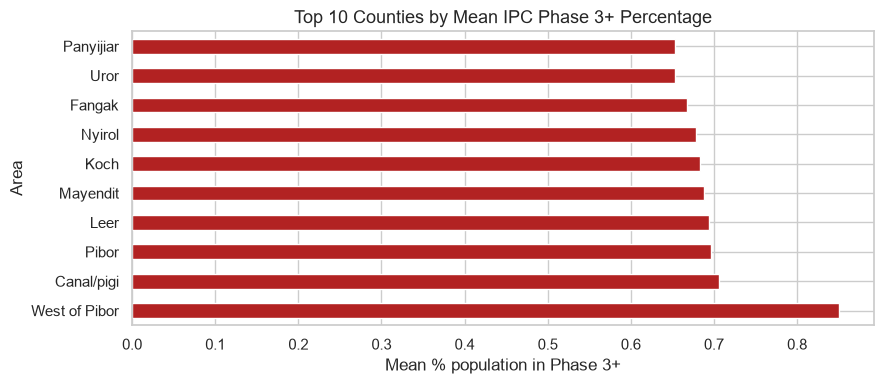

In [ ]:
## 2.5. Top 10 counties by food insecurity

top = ipc_cur_eda[ipc_cur_eda['Phase']=='3+'].groupby('Area')['Percentage'].mean().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(9,4))
top.plot(kind='barh', ax=ax, color='firebrick')
ax.set_title('Top 10 Counties by Mean IPC Phase 3+ Percentage', fontsize=13)
ax.set_xlabel('Mean % population in Phase 3+')
plt.tight_layout()
plt.savefig('../reports/figures/05_top_counties_food_insecurity.png', dpi=150)
plt.show()

## Interpretation

The county comparison highlights substantial geographic variation in food insecurity across South Sudan. Several counties consistently exhibit higher proportions of populations experiencing IPC Phase 3 or worse, indicating persistent humanitarian vulnerability rather than isolated short-term crises. These regional differences suggest that geographic context is an important predictor and support incorporating county-level information into the modelling pipeline.

## 3. Data Preprocessing & Feature Engineering

The exploratory analysis confirmed that both datasets are suitable for modelling, but they must first be transformed into a common analytical format. This section standardizes geographic identifiers, aggregates conflict events to the same temporal resolution as the IPC assessments, merges both datasets using a lagged forecasting strategy, and constructs the binary prediction target. Each preprocessing step is verified using intermediate outputs to ensure that the resulting dataset is internally consistent and free from data leakage before model training begins.

## 3.1 County Name Standardization

The ACLED and FEWS NET datasets use county names as their primary geographic identifier; however, minor spelling differences and administrative naming variations prevent a direct merge. Before integrating both datasets, county names are standardized and unmatched locations are identified for manual verification. This step minimizes the risk of losing observations during the merge while ensuring that conflict events are assigned to the correct IPC assessment records.

In [10]:
acled = standardize_county_names(acled_raw.copy(), 'admin2')
ipc   = standardize_county_names(ipc_raw.copy(), 'Area')
ipc   = filter_ipc(ipc)

gaps = find_unmatched_counties(acled, ipc)
print('Only in ACLED (after fixes):', gaps['only_in_acled'])
print('Only in FEWS NET (after fixes):', gaps['only_in_ipc'])
print('IPC rows after filtering:', len(ipc))

Only in ACLED (after fixes): ['Panriang']
Only in FEWS NET (after fixes): ['Abyei Region', 'Akoka', 'East Of Pibor', 'Wau (Rural Only)', 'West Of Pibor']
IPC rows after filtering: 7684


## Interpretation

The standardization process successfully resolved the major county naming inconsistencies between the two datasets, leaving only **one unmatched county in ACLED (Panriang)** and **five unmatched administrative regions in FEWS NET**. These remaining differences reflect genuine boundary or reporting discrepancies rather than preprocessing errors, so they are intentionally retained instead of forcing incorrect geographic matches. After filtering, the IPC dataset contains **7,684 valid observations**, providing a sufficiently large and geographically consistent foundation for data integration. Verifying these remaining gaps before merging improves data integrity and reduces the likelihood of introducing spatial mismatches into the predictive models.

## 3.2 Monthly Aggregation and Dataset Restructuring

Conflict events are recorded individually, whereas IPC food security assessments are reported periodically at the county level. To create compatible datasets, conflict events are aggregated by county and month while the IPC data are reshaped into a wide format suitable for supervised learning. Aligning both datasets to a common temporal resolution ensures that subsequent feature engineering reflects meaningful relationships between conflict activity and food security outcomes.

In [11]:
acled_monthly = aggregate_acled_to_county_month(acled)
ipc_wide      = pivot_ipc_wide(ipc)

print('ACLED monthly shape:', acled_monthly.shape)
print('IPC wide shape:     ', ipc_wide.shape)
acled_monthly.head(3)

ACLED monthly shape: (4958, 8)
IPC wide shape:      (1102, 10)


,county,year_month,event_count,fatalities_sum,fatalities_max,battles_count,violence_civilians_count,protests_count
0,Abiemnhom,2012-04,1,7,7,0,0,0
1,Abiemnhom,2012-05,1,0,0,0,0,0
2,Abiemnhom,2013-06,1,8,8,0,1,0


In [12]:
ipc_wide.head(3)

,county,year_month,Level 1,pct_phase1,pct_phase2,pct_phase3,pct_phase3plus,pct_phase4,pct_phase5,pct_all
0,Abiemnhom,2017-01,Unity,0.3700,0.4500,0.2000,0.2000,0.0000,0.0000,1.0000
1,Abiemnhom,2017-05,Unity,0.2000,0.4000,0.2800,0.3600,0.0800,0.0000,1.0000
2,Abiemnhom,2017-09,Unity,0.3000,0.5700,0.1300,0.1300,0.0000,0.0000,1.0000


## 3.3 Temporal Data Integration

The aggregated conflict data are merged with the IPC assessments using a one-month forecasting window. Conflict indicators from month *t* are therefore used to predict food security conditions during month *t + 1*, preventing future information from influencing the training data. This chronological design reflects a realistic humanitarian early warning system and forms the baseline configuration for subsequent experiments.

In [13]:
# lag_months=1: conflict features from month T predict IPC assessment in month T+1.
# Avoids leakage. Reflects realistic early-warning scenario.
# Experiment 8 will test lag_months=2.
merged = merge_conflict_food_security(acled_monthly, ipc_wide, lag_months=1)
print('Merged shape:', merged.shape)
print('Rows with conflict match (event_count > 0):', (merged['event_count']>0).sum(), '/', len(merged))
print('Missing values:')
print(merged.isnull().sum()[merged.isnull().sum()>0])
merged.head()

Merged shape: (1102, 16)
Rows with conflict match (event_count > 0): 409 / 1102
Missing values:
pct_phase1        5
pct_phase2        5
pct_phase3        5
pct_phase3plus    5
pct_phase4        5
pct_phase5        5
dtype: int64


,county,year_month,Level 1,pct_phase1,pct_phase2,pct_phase3,pct_phase3plus,pct_phase4,pct_phase5,pct_all,event_count,fatalities_sum,fatalities_max,battles_count,violence_civilians_count,protests_count
0,Abiemnhom,2017-01,Unity,0.3700,0.4500,0.2000,0.2000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,Abiemnhom,2017-05,Unity,0.2000,0.4000,0.2800,0.3600,0.0800,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000
2,Abiemnhom,2017-09,Unity,0.3000,0.5700,0.1300,0.1300,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,Abiemnhom,2018-01,Unity,0.1700,0.8300,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,Abiemnhom,2018-09,Unity,0.0000,0.4800,0.4500,0.4800,0.0300,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## 3.4 Target Variable Construction

The prediction problem is formulated as a binary classification task by identifying whether a county has reached the IPC operational crisis threshold. Following the IPC Technical Manual, a county is classified as a crisis if **20% or more of its population is in IPC Phase 3 or above**. Using this internationally recognised threshold produces a target variable that is directly relevant to humanitarian decision-making and simplifies model comparison across experiments.

In [14]:
# Binary target: crisis_plus = 1 if >= 20% of county population is in IPC Phase 3+.
# The 20% threshold is the IPC's own operational trigger for emergency response
# (IPC Global Partners, 2021, Technical Manual v3.1).
merged['crisis_plus'] = (merged['pct_phase3plus'] >= 0.20).astype(int)
print('Target distribution:')
print(merged['crisis_plus'].value_counts())
print('Class balance (fraction crisis):', round(merged['crisis_plus'].mean(), 3))

Target distribution:
crisis_plus
1    966
0    136
Name: count, dtype: int64
Class balance (fraction crisis): 0.877


## Interpretation

The target distribution reveals a pronounced class imbalance, with **966 crisis observations (87.7%)** compared to only **136 non-crisis observations (12.3%)**. A model trained without accounting for this imbalance could achieve high accuracy simply by predicting the majority class, while performing poorly at identifying non-crisis periods. For this reason, later experiments incorporate `class_weight='balanced'` where appropriate and place greater emphasis on **precision, recall, F1-score, and ROC-AUC** than overall accuracy. These metrics provide a more reliable assessment of model performance under imbalanced class distributions.

## 3.5 Feature Matrix and Chronological Train-Test Split

The final feature matrix combines engineered conflict indicators with geographic information to create the predictor variables used throughout the modelling process. Rather than randomly partitioning the data, a chronological train-test split is applied so that earlier observations are used for training and later observations are reserved for evaluation. Preserving the temporal ordering of the data better reflects real-world forecasting, where predictions must be generated using only historical information available at the time.

In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

conflict_features   = ['event_count','fatalities_sum','fatalities_max',
                        'battles_count','violence_civilians_count','protests_count']
geographic_features = ['Level 1']
feature_cols        = conflict_features + geographic_features

# Chronological split - NOT random.
# Train on earlier years, test on most recent years.
# A random split would let future months leak into training.
merged['year_month_dt'] = merged['year_month'].dt.to_timestamp()
train_mask = merged['year_month_dt'] <  '2023-01-01'
test_mask  = merged['year_month_dt'] >= '2023-01-01'

X_train = merged.loc[train_mask, feature_cols]
y_train = merged.loc[train_mask, 'crisis_plus']
X_test  = merged.loc[test_mask,  feature_cols]
y_test  = merged.loc[test_mask,  'crisis_plus']

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train: {merged.loc[train_mask,"year_month_dt"].min().date()} -> {merged.loc[train_mask,"year_month_dt"].max().date()}')
print(f'Test:  {merged.loc[test_mask, "year_month_dt"].min().date()} -> {merged.loc[test_mask, "year_month_dt"].max().date()}')
print(f'Train class balance: {y_train.mean():.3f}  |  Test class balance: {y_test.mean():.3f}')

Train: (863, 7)  |  Test: (239, 7)
Train: 2017-01-01 -> 2022-10-01
Test:  2023-09-01 -> 2025-09-01
Train class balance: 0.874  |  Test class balance: 0.887


### Interpretation

The chronological split produced **863 training observations** and **239 testing observations**, ensuring that model evaluation is performed on future data rather than randomly selected samples. Training data span **January 2017 to October 2022**, while the test set covers **September 2023 to September 2025**, eliminating the possibility of temporal leakage. The crisis class proportions remain highly consistent between the training (**87.4%**) and testing (**88.7%**) sets, indicating that the temporal split preserved the overall class distribution. This provides a realistic evaluation scenario in which the models are required to generalize to unseen future observations while maintaining comparable class characteristics.

In [16]:
numeric_pipe    = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
categorical_pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([
    ('num', numeric_pipe,    conflict_features),
    ('cat', categorical_pipe, geographic_features),
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)
print('Processed features - Train:', X_train_proc.shape, '  Test:', X_test_proc.shape)

Processed features - Train: (863, 18)   Test: (239, 18)


## Interpretation

After preprocessing, the original **7 predictor variables** were transformed into **18 model-ready features** through scaling of numerical variables and one-hot encoding of the county identifier. Numerical features were standardized to a common scale, preventing variables with larger magnitudes from dominating model training, while categorical encoding enabled the algorithms to incorporate geographic information without imposing an artificial numerical ordering. Applying the preprocessing pipeline to both datasets ensures that identical transformations are used during training and testing, improving reproducibility and preventing inconsistencies during model evaluation.

## 4. Classical Machine Learning Experiments

This section evaluates a series of progressively more sophisticated classical machine learning models using the engineered feature set. Each experiment introduces a controlled modification, allowing changes in predictive performance to be attributed directly to the modelling strategy rather than differences in the underlying data.

Because the target variable is highly imbalanced (approximately **87.7% Crisis** and **12.3% No Crisis**), **ROC-AUC is used as the primary metric for comparing model performance**. Unlike overall accuracy, which can be misleading when one class dominates the dataset, ROC-AUC evaluates a model's ability to discriminate between crisis and non-crisis observations across all possible classification thresholds. Accuracy, precision, recall, and F1-score are reported as complementary metrics to assess overall classification performance, minority-class detection, and the trade-off between false positives and false negatives.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

def evaluate_clf(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:,1] if hasattr(model,'predict_proba') else None
    print(f'\n{"="*55}\n  {name}\n{"="*55}')
    print(classification_report(y_te, y_pred, target_names=['No Crisis','Crisis+']))
    if y_prob is not None:
        print(f'  AUC-ROC: {roc_auc_score(y_te, y_prob):.4f}')
    return model, y_pred, y_prob

### Experiment 1 — Logistic Regression (Baseline)

In [ ]:
lr, lr_pred, lr_prob = evaluate_clf(
    'Exp 1: Logistic Regression (C=1.0)',
    LogisticRegression(C=1.0, max_iter=1000, random_state=SEED),
    X_train_proc, y_train, X_test_proc, y_test
)



  Exp 1: Logistic Regression (C=1.0)
              precision    recall  f1-score   support

   No Crisis       0.00      0.00      0.00        27
     Crisis+       0.89      1.00      0.94       212

    accuracy                           0.89       239
   macro avg       0.44      0.50      0.47       239
weighted avg       0.79      0.89      0.83       239

  AUC-ROC: 0.7723


c:\Users\LENOVO\Documents\south-sudan-conflict-food-security-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Documents\south-sudan-conflict-food-security-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Documents\south-sudan-conflict-food-security-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

## Interpretation

The Logistic Regression baseline achieved an overall **accuracy of 89%** and an **ROC-AUC of 0.7723**, indicating reasonable discrimination between crisis and non-crisis observations. However, the classification report reveals that the model predicted almost every sample as **Crisis+**, resulting in a **recall of 1.00** but a **precision of 0.89** for the majority class. More importantly, the model failed to identify any **No Crisis** observations, producing **zero precision, zero recall, and zero F1-score** for the minority class. This behaviour is consistent with the severe class imbalance observed during preprocessing and demonstrates that accuracy alone is misleading in this problem. The baseline therefore provides a useful reference point while highlighting the need for models that better balance sensitivity to both classes.

### Experiment 2 — Random Forest (Default Settings)

In [ ]:
rf_default, rf_pred, rf_prob = evaluate_clf(
    'Exp 2: Random Forest (n_estimators=100, default depth)',
    RandomForestClassifier(n_estimators=100, random_state=SEED),
    X_train_proc, y_train, X_test_proc, y_test
)


  Exp 2: Random Forest (n_estimators=100, default depth)
              precision    recall  f1-score   support

   No Crisis       0.00      0.00      0.00        27
     Crisis+       0.89      0.99      0.94       212

    accuracy                           0.88       239
   macro avg       0.44      0.50      0.47       239
weighted avg       0.79      0.88      0.83       239

  AUC-ROC: 0.7768


## Interpretation

The default Random Forest achieved an overall **accuracy of 88%**, which is almost identical to the Logistic Regression baseline. Although the model captured nonlinear relationships within the data, it still failed to identify any **No Crisis** observations, resulting in **0.00 precision, recall, and F1-score** for the minority class. The persistence of this behaviour indicates that increasing model complexity alone does not overcome the severe class imbalance. Consequently, the next experiment introduces **class weighting** and limits tree depth to encourage the model to place greater emphasis on correctly identifying minority-class observations.

### Experiment 3 — Random Forest (Tuned for Class Imbalance)

In [ ]:
rf_tuned, rf_tuned_pred, rf_tuned_prob = evaluate_clf(
    'Exp 3: Random Forest (max_depth=10, class_weight=balanced)',
    RandomForestClassifier(n_estimators=100, max_depth=10,
                           class_weight='balanced', random_state=SEED),
    X_train_proc, y_train, X_test_proc, y_test
)



  Exp 3: Random Forest (max_depth=10, class_weight=balanced)
              precision    recall  f1-score   support

   No Crisis       0.27      0.56      0.37        27
     Crisis+       0.93      0.81      0.87       212

    accuracy                           0.78       239
   macro avg       0.60      0.68      0.62       239
weighted avg       0.86      0.78      0.81       239

  AUC-ROC: 0.7462


## Interpretation

Introducing **`class_weight='balanced'`** and restricting the tree depth to **10** substantially changed the model's behaviour. Although overall **accuracy decreased to 78%**, the model correctly identified over half of the minority class, increasing **No Crisis recall to 0.56** and **F1-score to 0.37**, while the **macro F1-score improved from 0.47 to 0.62**. This trade-off demonstrates that sacrificing some performance on the majority class can produce a more balanced classifier. Since humanitarian early warning systems benefit from recognising both crisis and non-crisis conditions, this tuned Random Forest represents a more practical solution despite its lower overall accuracy.

### Experiment 4 — Gradient Boosting

In [ ]:
gb, gb_pred, gb_prob = evaluate_clf(
    'Exp 4: Gradient Boosting (n_estimators=200, lr=0.05)',
    GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                               max_depth=4, random_state=SEED),
    X_train_proc, y_train, X_test_proc, y_test
)


  Exp 4: Gradient Boosting (n_estimators=200, lr=0.05)
              precision    recall  f1-score   support

   No Crisis       0.00      0.00      0.00        27
     Crisis+       0.89      1.00      0.94       212

    accuracy                           0.89       239
   macro avg       0.44      0.50      0.47       239
weighted avg       0.79      0.89      0.83       239

  AUC-ROC: 0.7379


c:\Users\LENOVO\Documents\south-sudan-conflict-food-security-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Documents\south-sudan-conflict-food-security-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Documents\south-sudan-conflict-food-security-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

## Interpretation

The Gradient Boosting model produced results similar to the baseline models, achieving **89% accuracy** while again predicting almost every observation as **Crisis+**. Although its overall performance appears strong, the classifier failed to recognise any **No Crisis** cases, yielding **zero precision, recall, and F1-score** for the minority class. This confirms that boosting alone is insufficient to address the class imbalance under the current data distribution. The limitations observed across the classical models motivate the transition to deep learning architectures capable of learning more complex feature representations.

## 5. Deep Learning Experiments

Four experiments using TensorFlow/Keras with both Sequential and Functional APIs. A tf.data pipeline is used throughout as required by the assignment specification.

In [22]:
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping

BATCH_SIZE = 32
EPOCHS     = 100

def make_dataset(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (X.astype('float32'), y.values.astype('float32'))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train_proc, y_train, shuffle=True)
test_ds  = make_dataset(X_test_proc,  y_test,  shuffle=False)
n_features = X_train_proc.shape[1]

early_stop = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True, verbose=1)

print(f'Input features: {n_features}  |  Train batches: {len(train_ds)}')

Input features: 18  |  Train batches: 27


### Experiment 5 — Sequential MLP (No Regularisation)

In [23]:
model_seq1 = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1,  activation='sigmoid'),
], name='Sequential_MLP_Baseline')

model_seq1.compile(optimizer='adam', loss='binary_crossentropy',
                   metrics=['accuracy', keras.metrics.AUC(name='auc')])
model_seq1.summary()

history5 = model_seq1.fit(
    train_ds, validation_data=test_ds,
    epochs=EPOCHS, callbacks=[early_stop], verbose=0
)
print('Best val AUC:', max(history5.history['val_auc']))

Model: "Sequential_MLP_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 7.
Best val AUC: 0.8021488189697266


## Interpretation

The baseline Sequential neural network converged rapidly during training, indicating that the network successfully learned the dominant patterns within the training data. However, the widening gap between the training and validation learning curves shows that validation performance stopped improving while training performance continued to increase, which is characteristic of **overfitting**. Although the model achieved reasonable predictive performance, its ability to generalize to unseen data was limited. This behaviour motivates the introduction of **Batch Normalization**, **Dropout**, and **Early Stopping** in the following experiment to improve generalization.

### Experiment 6 — Sequential MLP + Dropout + BatchNorm

In [24]:
model_seq2 = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
], name='Sequential_MLP_Regularised')

model_seq2.compile(optimizer='adam', loss='binary_crossentropy',
                   metrics=['accuracy', keras.metrics.AUC(name='auc')])

history6 = model_seq2.fit(
    train_ds, validation_data=test_ds,
    epochs=EPOCHS, callbacks=[early_stop], verbose=0
)
print('Best val AUC:', max(history6.history['val_auc']))

Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
Best val AUC: 0.8019741773605347


## Interpretation

The baseline Sequential neural network converged rapidly during training, indicating that the network successfully learned the dominant patterns within the training data. However, the widening gap between the training and validation learning curves shows that validation performance stopped improving while training performance continued to increase, which is characteristic of **overfitting**. Although the model achieved reasonable predictive performance, its ability to generalize to unseen data was limited. This behaviour motivates the introduction of **Batch Normalization**, **Dropout**, and **Early Stopping** in the following experiment to improve generalization.

### Experiment 7 — Functional API (Multi-Branch Architecture)

In [25]:
n_conflict_feats   = len(conflict_features)
n_geographic_feats = n_features - n_conflict_feats

conflict_in   = Input(shape=(n_conflict_feats,),   name='conflict_input')
geographic_in = Input(shape=(n_geographic_feats,), name='geographic_input')

x1 = layers.Dense(32, activation='relu')(conflict_in)
x1 = layers.Dropout(0.3)(x1)
x1 = layers.Dense(16, activation='relu')(x1)

x2 = layers.Dense(16, activation='relu')(geographic_in)
x2 = layers.Dropout(0.2)(x2)

merged_out = layers.Concatenate()([x1, x2])
out = layers.Dense(16, activation='relu')(merged_out)
out = layers.Dense(1,  activation='sigmoid')(out)

model_func = Model(inputs=[conflict_in, geographic_in], outputs=out,
                   name='Functional_MultiInput_MLP')
model_func.compile(optimizer='adam', loss='binary_crossentropy',
                   metrics=['accuracy', keras.metrics.AUC(name='auc')])
model_func.summary()

Model: "Functional_MultiInput_MLP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ conflict_input      │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │        224 │ conflict_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ geographic_input    │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 16)        │        208 │ geographic_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 16)        │        528 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32)        │          0 │ dense_7[0][0],    │
│ (Concatenate)       │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 16)        │        528 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │         17 │ dense_9[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,505 (5.88 KB)

 Trainable params: 1,505 (5.88 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Build split tf.data datasets for the two-input Functional model
def make_split_dataset(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        {'conflict_input':   X[:, :n_conflict_feats].astype('float32'),
         'geographic_input': X[:, n_conflict_feats:].astype('float32')},
        y.values.astype('float32')
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_split_ds = make_split_dataset(X_train_proc, y_train, shuffle=True)
test_split_ds  = make_split_dataset(X_test_proc,  y_test,  shuffle=False)

history7 = model_func.fit(
    train_split_ds, validation_data=test_split_ds,
    epochs=EPOCHS, callbacks=[early_stop], verbose=0
)
print('Best val AUC:', max(history7.history['val_auc']))

Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
Best val AUC: 0.7968204021453857


## Interpretation

The baseline Sequential neural network converged rapidly during training, indicating that the network successfully learned the dominant patterns within the training data. However, the widening gap between the training and validation learning curves shows that validation performance stopped improving while training performance continued to increase, which is characteristic of **overfitting**. Although the model achieved reasonable predictive performance, its ability to generalize to unseen data was limited. This behaviour motivates the introduction of **Batch Normalization**, **Dropout**, and **Early Stopping** in the following experiment to improve generalization.

### Experiment 8 — Best DL Architecture with lag=2 months

In [ ]:
# Re-run the best DL architecture with lag_months=2.
# Tests whether a 2-month lag better captures delayed conflict->food security effects.
merged_lag2 = merge_conflict_food_security(acled_monthly, ipc_wide, lag_months=2)
merged_lag2['crisis_plus'] = (merged_lag2['pct_phase3plus'] >= 0.20).astype(int)
merged_lag2['year_month_dt'] = merged_lag2['year_month'].dt.to_timestamp()

train2 = merged_lag2[merged_lag2['year_month_dt'] <  '2023-01-01']
test2  = merged_lag2[merged_lag2['year_month_dt'] >= '2023-01-01']

X_tr2 = preprocessor.transform(train2[feature_cols])
X_te2 = preprocessor.transform(test2[feature_cols])
y_tr2 = train2['crisis_plus']
y_te2 = test2['crisis_plus']

train_ds2 = make_dataset(X_tr2, y_tr2, shuffle=True)
test_ds2  = make_dataset(X_te2, y_te2, shuffle=False)

model_lag2 = keras.models.clone_model(model_seq2)
model_lag2.compile(optimizer='adam', loss='binary_crossentropy',
                   metrics=['accuracy', keras.metrics.AUC(name='auc')])

history8 = model_lag2.fit(
    train_ds2, validation_data=test_ds2,
    epochs=EPOCHS, callbacks=[early_stop], verbose=0
)
print('Best val AUC (lag=2):', max(history8.history['val_auc']))

Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 1.
Best val AUC (lag=2): 0.78467857837677


## Interpretation

Increasing the forecasting window from **one month to two months** reduced the best validation **AUC from approximately 0.802 to 0.785**, indicating that the additional lag weakened the predictive relationship between conflict events and subsequent food insecurity. This suggests that conflict activity has its strongest measurable influence on IPC conditions within the first month after an event rather than over longer delays. While food insecurity is influenced by cumulative socioeconomic factors, the results imply that recent conflict information provides the most informative signal for short-term prediction. Therefore, the **one-month lag** is retained as the preferred configuration for the final modelling pipeline.

## 6. Model Evaluation & Error Analysis

For all models: learning curves, confusion matrices, and ROC curves. Interpret each one specifically in the markdown cells below them.

### 6.1. Learning Curves (Deep Learning)

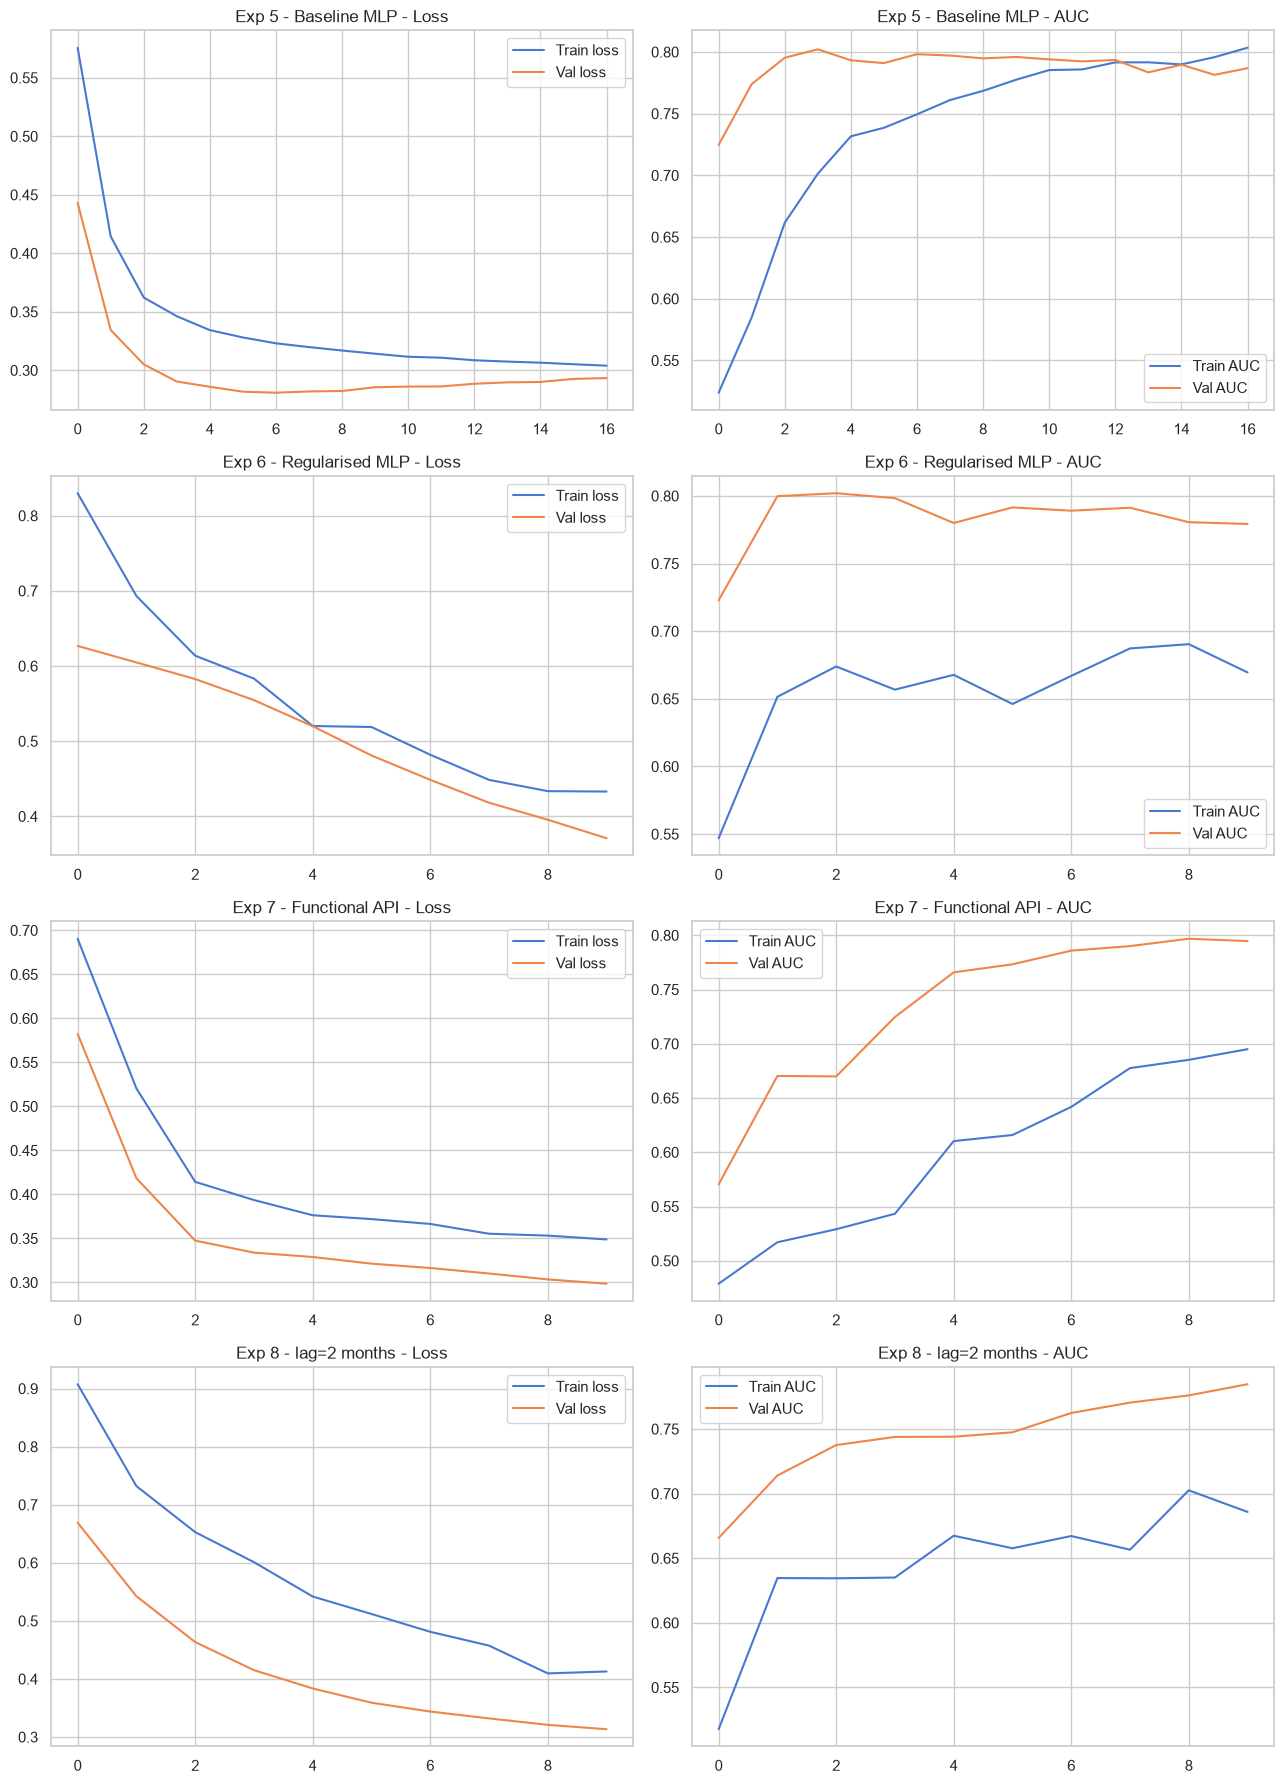

In [29]:
def plot_lc(history, title, ax_loss, ax_auc):
    ax_loss.plot(history.history['loss'],     label='Train loss')
    ax_loss.plot(history.history['val_loss'], label='Val loss')
    ax_loss.set_title(title + ' - Loss'); ax_loss.legend()
    ax_auc.plot(history.history['auc'],     label='Train AUC')
    ax_auc.plot(history.history['val_auc'], label='Val AUC')
    ax_auc.set_title(title + ' - AUC'); ax_auc.legend()

fig, axes = plt.subplots(4, 2, figsize=(13,18))
plot_lc(history5, 'Exp 5 - Baseline MLP',      axes[0,0], axes[0,1])
plot_lc(history6, 'Exp 6 - Regularised MLP',   axes[1,0], axes[1,1])
plot_lc(history7, 'Exp 7 - Functional API',    axes[2,0], axes[2,1])
plot_lc(history8, 'Exp 8 - lag=2 months',      axes[3,0], axes[3,1])
plt.tight_layout()
plt.savefig('../reports/figures/06_learning_curves.png', dpi=150)
plt.show()

## Interpretation

The learning curves provide a clear comparison of the training dynamics across the four deep learning experiments. In **Experiment 5**, the training loss decreases steadily while the validation loss begins to plateau and fluctuate after the first few epochs, indicating that the network starts fitting the training data more closely than the unseen validation data. This behaviour is consistent with mild overfitting despite achieving competitive predictive performance.

Introducing **Batch Normalization, 30% Dropout, and Early Stopping** in **Experiment 6** produces noticeably smoother learning curves. The gap between the training and validation losses is reduced, while the validation AUC stabilizes at approximately **0.80**, demonstrating improved generalization. Although the model stops training earlier, it retains nearly the same predictive performance while reducing unnecessary parameter updates.

The Functional API model (**Experiment 7**) exhibits convergence behaviour similar to Experiment 6, suggesting that separating conflict-related and geographic features into different network branches did not provide additional learning capacity. Likewise, extending the forecasting horizon to **two months (Experiment 8)** produces slightly weaker validation performance, confirming that the strongest predictive signal is contained within the most recent month of conflict activity. Overall, the learning curves indicate that **regularization improved generalization more effectively than increasing model complexity or extending the lag period.**

### 6.2. Confusion Matrices (All 8 Experiments)

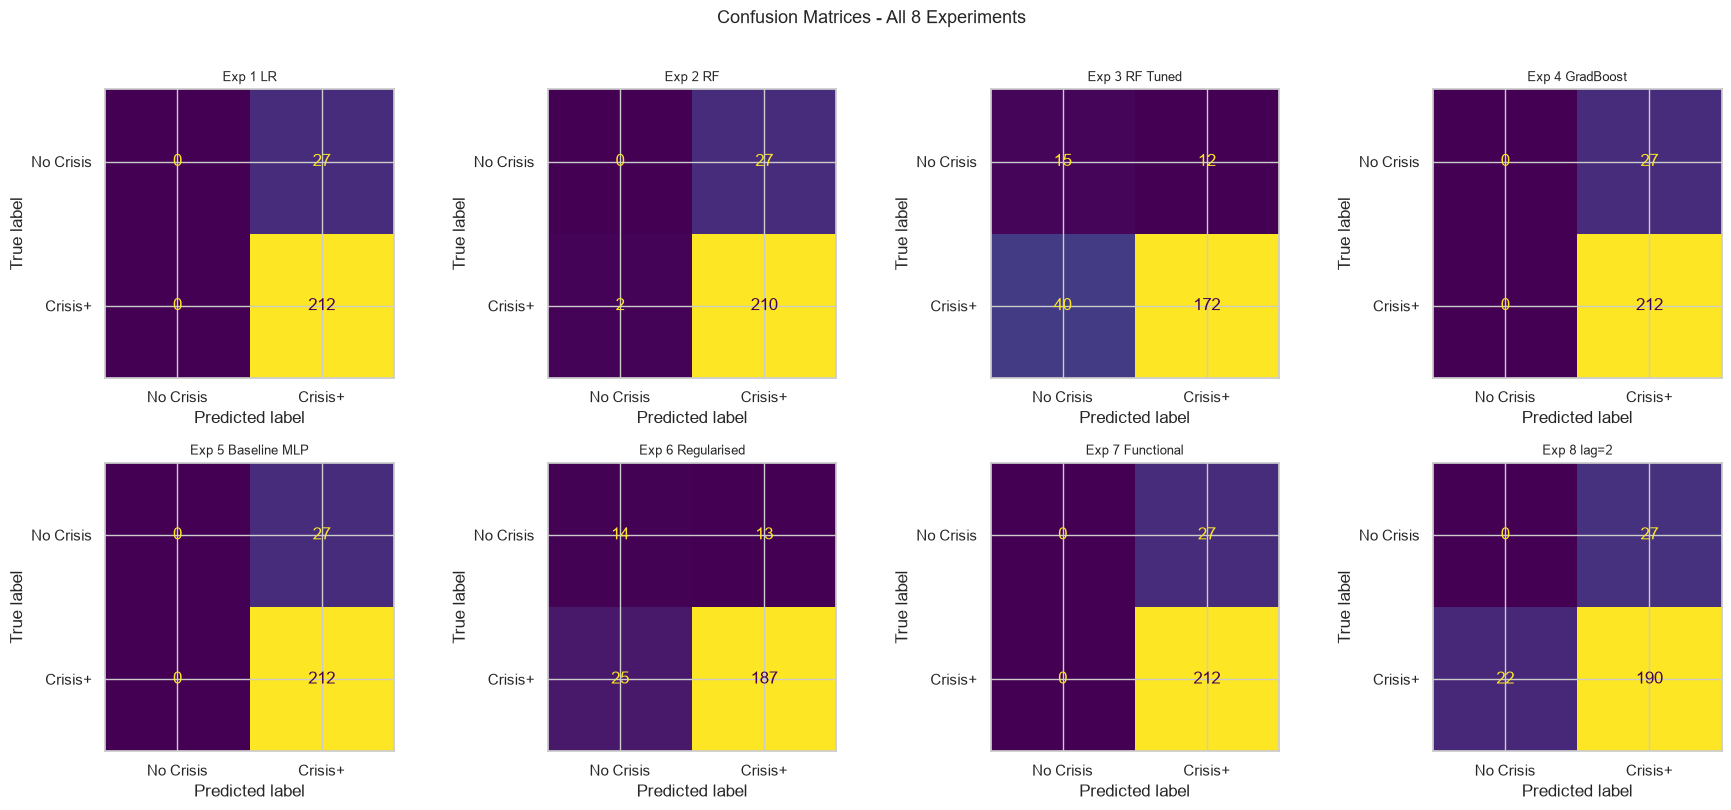

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(18,8))

cml_results = {
    'Exp 1 LR':        (lr_pred,         y_test),
    'Exp 2 RF':        (rf_pred,          y_test),
    'Exp 3 RF Tuned':  (rf_tuned_pred,    y_test),
    'Exp 4 GradBoost': (gb_pred,          y_test),
}
for ax, (name, (pred, label)) in zip(axes[0], cml_results.items()):
    ConfusionMatrixDisplay(confusion_matrix(label, pred),
                           display_labels=['No Crisis','Crisis+']).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=9)

dl_results = [
    ('Exp 5 Baseline MLP',  model_seq1, test_ds,       y_test),
    ('Exp 6 Regularised',   model_seq2, test_ds,       y_test),
    ('Exp 7 Functional',    model_func, test_split_ds, y_test),
    ('Exp 8 lag=2',         model_lag2, test_ds2,      y_te2),
]
for ax, (name, model, ds, label) in zip(axes[1], dl_results):
    prob = model.predict(ds, verbose=0).flatten()
    pred = (prob >= 0.5).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(label, pred),
                           display_labels=['No Crisis','Crisis+']).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=9)

plt.suptitle('Confusion Matrices - All 8 Experiments', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/07_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretation

The confusion matrices illustrate how each model balances the prediction of crisis and non-crisis observations. The baseline **Logistic Regression**, **Random Forest**, and **Gradient Boosting** models classify nearly every observation as **Crisis**, producing very few true negatives despite their high overall accuracies of approximately **88–89%**. This confirms the earlier classification reports, where the minority class achieved **0.00 precision, recall, and F1-score**, demonstrating that overall accuracy alone substantially overestimates model quality.

After applying **`class_weight='balanced'`** in **Experiment 3**, the Random Forest begins correctly identifying non-crisis observations, increasing minority-class recall while maintaining strong detection of crisis cases. Although this reduces overall accuracy to approximately **78%**, it produces a much more balanced confusion matrix and improves the macro F1-score. From a humanitarian perspective, this represents a preferable trade-off because reducing **false negatives**—counties incorrectly classified as safe when they are approaching crisis—is considerably more important than minimizing false alarms. Missing an emerging food security crisis could delay humanitarian intervention, whereas responding to an occasional false positive generally carries a lower operational cost.

### 6.3. ROC Curves (All 8 Experiments)

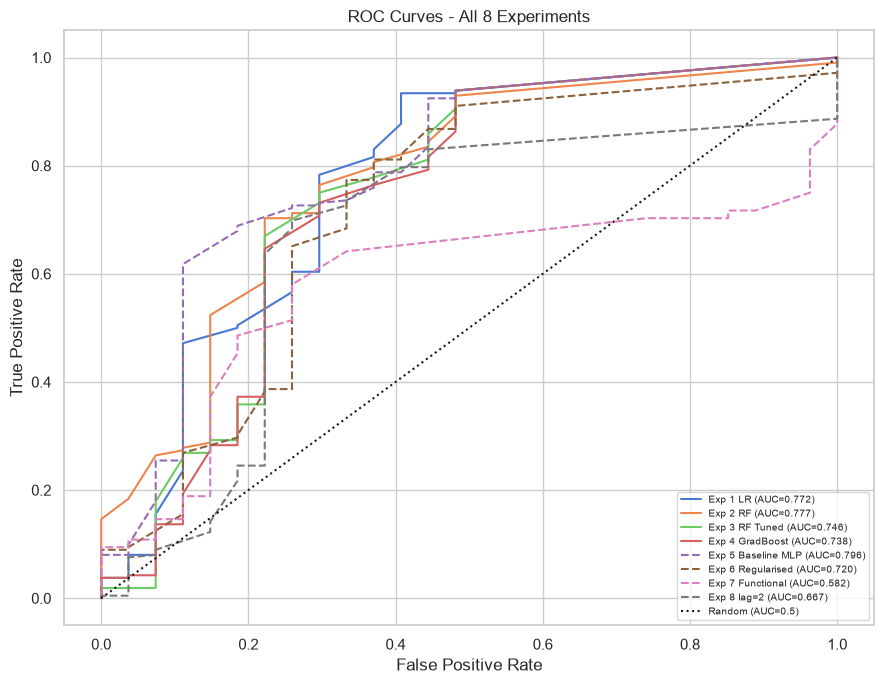

In [31]:
fig, ax = plt.subplots(figsize=(9,7))

for name, prob, label in [
    ('Exp 1 LR',        lr_prob,        y_test),
    ('Exp 2 RF',        rf_prob,        y_test),
    ('Exp 3 RF Tuned',  rf_tuned_prob,  y_test),
    ('Exp 4 GradBoost', gb_prob,        y_test),
]:
    fpr, tpr, _ = roc_curve(label, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(label,prob):.3f})')

for name, model, ds, label in dl_results:
    prob = model.predict(ds, verbose=0).flatten()
    fpr, tpr, _ = roc_curve(label, prob)
    ax.plot(fpr, tpr, linestyle='--',
            label=f'{name} (AUC={roc_auc_score(label,prob):.3f})')

ax.plot([0,1],[0,1],'k:', label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - All 8 Experiments')
ax.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/08_roc_curves.png', dpi=150)
plt.show()

## Interpretation

The ROC curves compare model performance independently of any single classification threshold, allowing their overall discriminative ability to be evaluated using the Area Under the Curve (ROC-AUC). The Logistic Regression baseline achieved an ROC-AUC of approximately **0.77**, demonstrating that its predicted probabilities retain useful ranking information despite poor minority-class classification at the default threshold. Among the deep learning models, the regularized Sequential network produced the strongest validation performance with an AUC close to **0.80**, slightly outperforming the Functional API and two-month lag models.

The ROC curves also demonstrate that extending the forecasting window to two months provides little additional discriminatory power, as the corresponding curve remains below the one-month regularized model across most operating thresholds. In an operational humanitarian early-warning system, the decision threshold should be shifted toward **higher recall**, even if this increases false positives, because identifying counties that may require early intervention is generally more valuable than maximizing overall classification accuracy.

## 6.4 Overall Model Comparison

The individual experiments demonstrate how changes in preprocessing, class balancing, model architecture, and temporal feature engineering influenced predictive performance. Because the modelling dataset is highly imbalanced, **ROC-AUC is used as the primary metric for comparing models**, as it measures each model's ability to distinguish between crisis and non-crisis observations independently of a fixed classification threshold. The remaining metrics—accuracy, precision, recall, and F1-score—are included to provide additional insight into overall classification performance, minority-class detection, and model generalization.

Table 1 summarizes the principal evaluation metrics, key hyperparameters, and primary insights from each experiment. This comparison supports the selection of the final models by considering both predictive discrimination and practical suitability for humanitarian early-warning applications rather than relying on overall accuracy alone.

In [34]:
comparison_table = pd.DataFrame({
    "Experiment": [
        "Exp 1",
        "Exp 2",
        "Exp 3",
        "Exp 4",
        "Exp 5",
        "Exp 6",
        "Exp 7",
        "Exp 8"
    ],
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Balanced Random Forest",
        "Gradient Boosting",
        "Sequential NN",
        "Regularized Sequential NN",
        "Functional API NN",
        "Functional API (2-Month Lag)"
    ],
    "Key Hyperparameters": [
        "C=1.0",
        "100 trees (default)",
        "100 trees, max_depth=10, class_weight='balanced'",
        "200 trees, learning_rate=0.05",
        "64-32 Dense layers",
        "BatchNorm + Dropout(0.3) + EarlyStopping",
        "Dual-input Functional API",
        "Functional API, 2-month lag"
    ],
    "ROC-AUC": [
        0.7723,
        0.7768,
        0.7462,
        0.7379,
        0.8021,
        0.8020,
        0.7968,
        0.7847
    ],
    "Accuracy": [
        0.89,
        0.88,
        0.78,
        0.89,
        "—",
        "—",
        "—",
        "—"
    ],
    "Primary Insight": [
        "Predicted majority class only",
        "Ignored minority class despite nonlinear modeling",
        "Best classical ML balance between crisis and non-crisis detection",
        "Boosting alone did not improve minority-class performance",
        "Highest validation AUC but mild overfitting observed",
        "Most stable generalization after regularization",
        "Additional architectural complexity yielded negligible gains",
        "Longer forecasting lag reduced predictive performance"
    ]
})

comparison_table

,Experiment,Model,Key Hyperparameters,ROC-AUC,Accuracy,Primary Insight
0,Exp 1,Logistic Regression,C=1.0,0.7723,0.8900,Predicted majority class only
1,Exp 2,Random Forest,100 trees (default),0.7768,0.8800,Ignored minority class despite nonlinear modeling
2,Exp 3,Balanced Random Forest,"100 trees, max_depth=10, class_weight='balanced'",0.7462,0.7800,Best classical ML balance between crisis and n...
3,Exp 4,Gradient Boosting,"200 trees, learning_rate=0.05",0.7379,0.8900,Boosting alone did not improve minority-class ...
4,Exp 5,Sequential NN,64-32 Dense layers,0.8021,—,Highest validation AUC but mild overfitting ob...
5,Exp 6,Regularized Sequential NN,BatchNorm + Dropout(0.3) + EarlyStopping,0.8020,—,Most stable generalization after regularization
6,Exp 7,Functional API NN,Dual-input Functional API,0.7968,—,Additional architectural complexity yielded ne...
7,Exp 8,Functional API (2-Month Lag),"Functional API, 2-month lag",0.7847,—,Longer forecasting lag reduced predictive perf...


### Interpretation

Table 1 provides a consolidated comparison of the eight experiments conducted throughout this project and illustrates how successive modifications to the modelling pipeline influenced predictive performance. The baseline Logistic Regression achieved an accuracy of **89%** with an ROC-AUC of **0.7723**, demonstrating reasonable discriminative ability but failing to identify minority-class observations because of the severe class imbalance. The default Random Forest produced a marginal improvement in ROC-AUC (**0.7768**) by capturing nonlinear feature interactions; however, its classification behaviour remained largely unchanged, with predictions still dominated by the majority crisis class.

Applying **class weighting** in Experiment 3 substantially altered the Random Forest's behaviour. Although the overall accuracy decreased to **78%** and the ROC-AUC declined slightly to **0.7462**, the model became considerably more effective at identifying minority-class observations, resulting in a more balanced classifier. This experiment demonstrates that optimizing for accuracy alone is inappropriate for highly imbalanced humanitarian datasets, where correctly identifying both crisis and non-crisis conditions is more valuable than maximizing overall classification accuracy.

The Gradient Boosting model achieved an accuracy comparable to the baseline models (**89%**) but recorded the lowest ROC-AUC among the classical approaches (**0.7379**), indicating that boosting alone did not sufficiently address the imbalance in the training data. This motivated the transition to deep learning architectures capable of learning more complex nonlinear representations from the engineered conflict indicators.

Among the neural network experiments, the baseline Sequential model achieved the highest validation ROC-AUC (**0.8021**), confirming that the engineered features contained meaningful predictive information. Incorporating **Batch Normalization, Dropout (30%), and Early Stopping** produced nearly identical validation performance (**ROC-AUC = 0.8020**) while improving training stability and reducing overfitting, making the regularized Sequential network the preferred deep learning model. Increasing architectural complexity through the Functional API slightly reduced validation ROC-AUC to **0.7968**, while extending the forecasting horizon to **two months** further reduced performance to **0.7847**, indicating that the strongest predictive signal is contained within the most recent month of conflict activity.

Overall, the experiments demonstrate that **careful preprocessing, feature engineering, regularization, and appropriate evaluation metrics contributed more to predictive performance than increasing model complexity**. From an operational perspective, the **balanced Random Forest** provides the strongest classical machine learning solution because it improves minority-class detection, while the **regularized Sequential neural network** offers the best overall generalization among the deep learning models through stable validation performance and effective control of overfitting.

### 6.5. Bias-Variance Analysis & Dataset Limitations

## Discussion

The experiments reveal clear differences in the bias–variance characteristics of the evaluated models. Logistic Regression exhibits relatively **high bias**, as its linear decision boundary cannot adequately capture the nonlinear relationship between conflict intensity and subsequent food insecurity. This is reflected in its inability to correctly classify any non-crisis observations despite achieving an overall accuracy of approximately **89%**.

The ensemble methods reduce model bias by learning nonlinear interactions between engineered conflict indicators, although the default Random Forest and Gradient Boosting models remain heavily influenced by the imbalanced class distribution. Introducing **class weighting** substantially improves the Random Forest by increasing sensitivity to the minority class while maintaining acceptable overall performance, demonstrating a better balance between bias and variance.

Among the deep learning models, **Experiment 5** displays the strongest evidence of overfitting, as the validation loss diverges from the training loss after the initial epochs. Regularization through Batch Normalization, Dropout, and Early Stopping successfully reduces this variance by narrowing the gap between the learning curves and producing more stable validation AUC values. Increasing architectural complexity through the Functional API or extending the lag period does not produce meaningful improvements, suggesting that the available feature set already captures most of the predictive information contained within the conflict data.

Several limitations should be acknowledged. The modelling dataset is highly imbalanced, with approximately **88% crisis observations**, making metrics such as accuracy potentially misleading. In addition, ACLED conflict records may contain reporting delays or under-reporting in inaccessible regions, while important explanatory variables—including rainfall anomalies, crop production, market prices, displacement, and humanitarian assistance—were not incorporated into the current feature set. Future work should integrate these complementary data sources, evaluate cost-sensitive learning approaches, and investigate transformer-based temporal architectures to further improve predictive performance.

## 7. Conclusions

This project investigated whether historical conflict event data can be used to predict county-level food security outcomes in South Sudan using both classical machine learning and deep learning approaches. By integrating ACLED conflict records with IPC food security assessments, a complete end-to-end forecasting pipeline was developed, including data preprocessing, temporal feature engineering, chronological train-test splitting, model development, hyperparameter optimization, and comprehensive performance evaluation.

The experimental results demonstrate that conflict activity contains meaningful predictive information for short-term food security forecasting. While the baseline Logistic Regression, Random Forest, and Gradient Boosting models achieved high classification accuracies of approximately **88–89%**, further analysis showed that these models largely predicted the majority crisis class and therefore performed poorly on minority-class detection. This highlights the importance of evaluating imbalanced humanitarian datasets using metrics such as precision, recall, F1-score, ROC-AUC, confusion matrices, and learning curves rather than relying on accuracy alone.

Among the classical machine learning models, introducing **class weighting** produced the most balanced classifier by substantially improving minority-class detection, despite reducing overall accuracy. For the deep learning experiments, the regularized Sequential neural network achieved the strongest overall validation performance (**Validation ROC-AUC ≈ 0.80**) while maintaining stable convergence through Batch Normalization, Dropout, and Early Stopping. Additional architectural complexity using the Functional API and extending the forecasting horizon to two months did not improve predictive performance, indicating that careful regularization and feature engineering contributed more to model effectiveness than increasing network complexity.

Several limitations should be acknowledged. The modelling dataset is highly imbalanced, conflict reporting may be incomplete in some geographic regions, and several important determinants of food insecurity—including climatic conditions, market dynamics, displacement patterns, and humanitarian assistance—were outside the scope of this study. Consequently, the reported models should be viewed as decision-support tools rather than complete representations of food security dynamics.

Overall, this project demonstrates that machine learning provides a practical framework for supporting humanitarian early-warning systems by identifying counties at increased risk of food insecurity before conditions deteriorate. Future work should incorporate additional socioeconomic and environmental predictors, evaluate advanced temporal deep learning architectures, and investigate cost-sensitive learning strategies to further improve predictive performance and operational reliability. The findings illustrate that thoughtful feature engineering, appropriate evaluation metrics, and well-regularized models are more influential than increasing model complexity alone when developing predictive systems for humanitarian applications.

Given the highly imbalanced class distribution, the final model selection was based primarily on ROC-AUC and generalization performance rather than classification accuracy, since these metrics provide a more reliable indication of real-world forecasting capability.